In [1]:
!pip install bayesian-optimization lightgbm imblearn optbinning probatus 

In [2]:
import os

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import re #regular expression

import matplotlib.pyplot as plt #For plotting graphs
import matplotlib.ticker as mtick
#plt.style.use('ggplot')
#include plots in the notebook
%matplotlib inline 
import seaborn as sns #For plotting graphs
#sns.set(style='darkgrid')
sns.set_style("whitegrid")
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder #for creating dummy variables out of categorical variables
from sklearn.metrics import precision_score, recall_score, f1_score, roc_auc_score, accuracy_score, classification_report, \
confusion_matrix, mean_squared_error, balanced_accuracy_score,roc_curve
import matplotlib.pyplot as plt

from sklearn.experimental import enable_halving_search_cv
from sklearn.model_selection import HalvingGridSearchCV, GridSearchCV,RandomizedSearchCV
from scipy.stats import chi2_contingency

# Classifier Libraries
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from lightgbm import LGBMClassifier
import lightgbm as lgb

# Undersampling and Oversampling Libraries
from sklearn.model_selection import train_test_split
from imblearn.over_sampling import SMOTE, ADASYN
from imblearn.under_sampling import NearMiss, CondensedNearestNeighbour,TomekLinks
from imblearn.combine import SMOTEENN, SMOTETomek
from imblearn.metrics import classification_report_imbalanced

from sklearn.preprocessing import OrdinalEncoder

from optbinning import OptimalBinning

# Recursive Feature Elimination
import warnings
# warnings.filterwarnings("ignore", message=".*The 'nopython' keyword.*")
warnings.filterwarnings('ignore')
from probatus.feature_elimination import ShapRFECV

# Classifier Libraries
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import GradientBoostingClassifier

#utilities
import collections

import warnings
warnings.filterwarnings("ignore")

# from LGBMBayesianOptimization import bayes_parameter_opt_lgb
from functions import *

import openpyxl

pd.set_option('display.max_colwidth', None)

import shap
# print the JS visualization code to the notebook
shap.initjs()

In [3]:
run_date_str = '20231010'
s3_output = f's3://toast-datascience-sandbox/PradeepA/pre90_pd_model/{run_date_str}' # output directory

# df = pd.read_parquet(f's3://toast-datascience-sandbox/PradeepA/pre90_pd_model/{run_date_str}/processed_train.parquet') 

df_train = pd.read_parquet(os.path.join(s3_output, 'train_xs.parquet'))
df_val =pd.read_parquet(os.path.join(s3_output, 'test_xs.parquet'))

In [4]:
print(df_train.shape)
print(df_val.shape)

(253090, 33)
(60212, 33)


In [5]:
#Keep valid states
list_us_state_codes = [
    "AL", "AK", "AZ", "AR", "CA", "CO", "CT", "DE", "FL", "GA",
    "HI", "ID", "IL", "IN", "IA", "KS", "KY", "LA", "ME", "MD",
    "MA", "MI", "MN", "MS", "MO", "MT", "NE", "NV", "NH", "NJ",
    "NM", "NY", "NC", "ND", "OH", "OK", "OR", "PA", "RI", "SC", "SD",
    "TN", "TX", "UT", "VT", "VA", "WA", "WV", "WI", "WY"
]
df_train = df_train[df_train['state'].isin(list_us_state_codes)]
df_val = df_val[df_val['state'].isin(list_us_state_codes)]

In [6]:
print(df_train.shape)
print(df_val.shape)

(250670, 33)
(58589, 33)


In [7]:
df_train.info()

<class 'pandas.core.frame.DataFrame'>
Index: 250670 entries, 3227412 to 85932476
Data columns (total 33 columns):
 #   Column                           Non-Null Count   Dtype         
---  ------                           --------------   -----         
 0   rid                              250670 non-null  int64         
 1   dt                               250670 non-null  datetime64[ns]
 2   label_90                         250670 non-null  float64       
 3   state                            250670 non-null  object        
 4   parent_market_segment            250670 non-null  object        
 5   restaurant_type                  250670 non-null  object        
 6   account_restaurant_category      250477 non-null  object        
 7   days_delta_first_obs             250670 non-null  int64         
 8   first_loan_date                  27014 non-null   datetime64[ns]
 9   days_with_toast                  250670 non-null  int64         
 10  months_with_toast                250670 n

In [8]:
df_train = df_train[df_train['days_with_toast']<=90]
df_val = df_val[df_val['days_with_toast']<=90]

In [9]:
print('Not Default vs Default\n',df_train.label_90.value_counts(dropna=False))
var = round(df_train.label_90.value_counts(normalize=True,dropna=False).loc[1]*100,2)
print("The event rate is {}%".format(var))

Not Default vs Default
 label_90
0.0    236073
1.0     12840
Name: count, dtype: int64
The event rate is 5.16%


In [10]:
print('Not Default vs Default\n',df_val.label_90.value_counts(dropna=False))
var = round(df_val.label_90.value_counts(normalize=True,dropna=False).loc[1]*100,2)
print("The event rate is {}%".format(var))

Not Default vs Default
 label_90
0.0    54932
1.0     3069
Name: count, dtype: int64
The event rate is 5.29%


In [11]:
df_val['dt'].min()

Timestamp('2023-02-21 00:00:00')

# Create seasonality features

In [12]:
df_train['day_of_year'] = df_train['dt'].dt.dayofyear
df_train['month'] = df_train['dt'].dt.month
df_train['quarter'] = df_train['dt'].dt.quarter
df_train['month'] = df_train['dt'].dt.month
df_train['quarter'] = df_train['dt'].dt.quarter
df_val['day_of_year'] = df_val['dt'].dt.dayofyear
df_val['month'] = df_val['dt'].dt.month
df_val['quarter'] = df_val['dt'].dt.quarter

# Train/Test Split

In [13]:
data = df_train.copy()
y = data.label_90
remove_list = ['label_90']
stratify_class = data[['label_90', 'state']]
X = data.drop(columns=remove_list)

X_train, X_test, y_train, y_test = train_test_split(X, y,stratify=y, test_size=.25, random_state=42)
X_train.shape, X_test.shape

((186684, 35), (62229, 35))

In [14]:
df_train = pd.merge(X_train,y_train,left_index=True,right_index=True,how='inner')
df_test = pd.merge(X_test,y_test,left_index=True,right_index=True,how='inner')

In [15]:
print('Not Default vs Default\n',df_train.label_90.value_counts(dropna=False))
var = round(df_train.label_90.value_counts(normalize=True,dropna=False).loc[1]*100,2)
print("The event rate is {}%".format(var))

Not Default vs Default
 label_90
0.0    177054
1.0      9630
Name: count, dtype: int64
The event rate is 5.16%


In [16]:
print('Not Default vs Default\n',df_test.label_90.value_counts(dropna=False))
var = round(df_test.label_90.value_counts(normalize=True,dropna=False).loc[1]*100,2)
print("The event rate is {}%".format(var))

Not Default vs Default
 label_90
0.0    59019
1.0     3210
Name: count, dtype: int64
The event rate is 5.16%


In [33]:
print('Not Default vs Default\n',df_val.label_90.value_counts(dropna=False))
var = round(df_val.label_90.value_counts(normalize=True,dropna=False).loc[1]*100,2)
print("The event rate is {}%".format(var))

Not Default vs Default
 label_90
0.0    54932
1.0     3069
Name: count, dtype: int64
The event rate is 5.29%


# LGBM variable list preparation

In [17]:
feature_list = [
    'rid', 'dt', 'label_90',
    'state', 'parent_market_segment', 'restaurant_type', 'account_restaurant_category',
    'day_of_year', 'month', 'quarter',
    'first_loan_date', 'days_with_toast', 'months_with_toast', 'first_loan_date_90d',
    'has_oo_mod', 'has_gc_mod', 'noprocessing_last_90d',
    'gpv_mean_90d', 'gpv_mean_28d', 'gpv_median_28d', 'gpv_cv_90d', 'log_gpv_std_90d',
    'gpv_median_28d_mean_90d_diff', 'gpv_median_28d_median_84d_diff',
    'gpv_median_28d_28ddiff', 'gpv_median_28d_84ddiff',
    'gpv_per_hour_median_28d', 'gpv_per_hour_median_28d_28ddiff', 
    'days_no_gpv_90d', 'days_no_gpv_28d', 'days_no_gpv_28d_28ddiff',
    'tx_hours_mean_14d', 'tx_hours_median_14d', 'tx_hours_median_28d', 'tx_hours_median_28d_28ddiff',
]

In [18]:

vars_cat = [
    # 'state',
            'account_restaurant_category',
            'parent_market_segment',
           ]
vars_noorder = ['day_of_year']
vars_asc = ['days_no_gpv_28d',
            'days_no_gpv_90d',
            # 'days_no_gpv_28d_28ddiff',
           'gpv_cv_90d',
            # 'noprocessing_last_90d',
           ]
vars_des =[  'has_gc_mod',
           # 'has_oo_mod',
           'gpv_mean_28d',
           'gpv_mean_90d',
           # 'gpv_median_28d_mean_90d_diff',
           'gpv_median_28d_28ddiff',
           'gpv_per_hour_median_28d',
           'tx_hours_median_14d',
           # 'tx_hours_median_28d',
           'tx_hours_median_28d_28ddiff',
          ]
pd_features = vars_cat + vars_noorder + vars_asc + vars_des
var_monotone = [0] * len(vars_cat + vars_noorder) +[1] * len(vars_asc) + [-1] * len(vars_des)
df_train_encoded = df_train.copy()
df_test_encoded = df_test.copy()
df_val_encoded = df_val.copy()
oe = OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=np.nan)
df_train_encoded[vars_cat] = oe.fit_transform(df_train_encoded[vars_cat])
df_test_encoded[vars_cat] = oe.fit_transform(df_test_encoded[vars_cat])
df_val_encoded[vars_cat] = oe.fit_transform(df_val_encoded[vars_cat])

In [19]:
df = pd.concat([df_train,df_test,df_val])
df[pd_features].info()

<class 'pandas.core.frame.DataFrame'>
Index: 306914 entries, 73740051 to 89426422
Data columns (total 13 columns):
 #   Column                       Non-Null Count   Dtype  
---  ------                       --------------   -----  
 0   account_restaurant_category  306722 non-null  object 
 1   parent_market_segment        306914 non-null  object 
 2   day_of_year                  306914 non-null  int32  
 3   days_no_gpv_28d              306914 non-null  float64
 4   days_no_gpv_90d              306914 non-null  float64
 5   gpv_cv_90d                   306914 non-null  float64
 6   has_gc_mod                   306914 non-null  int64  
 7   gpv_mean_28d                 306914 non-null  float64
 8   gpv_mean_90d                 306914 non-null  float64
 9   gpv_median_28d_28ddiff       306914 non-null  float64
 10  gpv_per_hour_median_28d      306914 non-null  float64
 11  tx_hours_median_14d          306914 non-null  float64
 12  tx_hours_median_28d_28ddiff  306914 non-null  float64


In [20]:
from LGBMBayesianOptimization import bayes_parameter_opt_lgb
opt_res, opt_params = bayes_parameter_opt_lgb(df_train_encoded[pd_features], y_train, categorical_feats = vars_cat, init_round=15, \
                                              opt_round=15, n_folds=3, random_seed=42, n_estimators=100, monotonic_contraints = var_monotone)
opt_res, opt_params

|   iter    |  target   | baggin... | featur... | lambda_l1 | lambda_l2 | learni... | max_depth | min_ch... | min_da... | min_sp... | min_su... | num_le... |
-------------------------------------------------------------------------------------------------------------------------------------------------------------
| 1         | 0.8645    | 0.8749    | 0.8581    | 3.66      | 2.993     | 0.05525   | 6.092     | 7.614     | 17.99     | 0.301     | 0.007084  | 15.62     |
| 2         | 0.8677    | 0.994     | 0.7576    | 1.062     | 0.9091    | 0.06319   | 7.13      | 28.61     | 11.48     | 0.1463    | 0.006122  | 19.18     |
| 3         | 0.8657    | 0.8584    | 0.3614    | 2.28      | 3.926     | 0.06791   | 8.6       | 31.66     | 5.697     | 0.3042    | 0.001714  | 16.95     |
| 4         | 0.8589    | 0.9898    | 0.8708    | 4.042     | 1.523     | 0.03832   | 9.79      | 24.81     | 6.831     | 0.2481    | 0.0003535 | 42.28     |
| 5         | 0.8696    | 0.8518    | 0.6131    | 1.

(0.8711854730276244,
 {'bagging_fraction': 0.8543564960285752,
  'feature_fraction': 0.7194454113604639,
  'lambda_l1': 3.652475229042257,
  'lambda_l2': 1.4566516155309146,
  'learning_rate': 0.13438537525338484,
  'max_depth': 9.539749002876809,
  'min_child_weight': 28.648816730546844,
  'min_data_in_leaf': 11.841623561618356,
  'min_split_gain': 0.050955988822122066,
  'min_sum_hessian_in_leaf': 0.00435525077060588,
  'num_leaves': 44.76490509248285})

In [21]:
param_dict = opt_params
seed=42

param_lgb = {
        'num_leaves': int(param_dict['num_leaves']),
        'min_data_in_leaf': int(param_dict['min_data_in_leaf']), 
        'learning_rate':param_dict['learning_rate'],
        'min_sum_hessian_in_leaf': param_dict['min_sum_hessian_in_leaf'],
        'bagging_fraction': param_dict['bagging_fraction'], 
        'feature_fraction': param_dict['feature_fraction'],
        'lambda_l1': param_dict['lambda_l1'],
        'lambda_l2': param_dict['lambda_l2'],
        'min_gain_to_split': param_dict['min_split_gain'],
        'max_depth': int(param_dict['max_depth']), 
        'save_binary': True,
        'seed': seed,
        'feature_fraction_seed': seed,
        'bagging_seed': seed,
        'drop_seed': seed,
        'data_random_seed': seed,
        'objective': 'binary',
        'boosting_type': 'gbdt',
        'verbose': -1,
        'metric': 'auc',
        'is_unbalance': False,
        'boost_from_average': False,
        'monotone_constraints': var_monotone
    }

model = lgb.LGBMClassifier(importance_type='gain', **param_lgb)

model.fit(df_train_encoded[pd_features], y_train)

LGBMClassifier(bagging_fraction=0.8543564960285752, bagging_seed=42,
               boost_from_average=False, data_random_seed=42, drop_seed=42,
               feature_fraction=0.7194454113604639, feature_fraction_seed=42,
               importance_type='gain', is_unbalance=False,
               lambda_l1=3.652475229042257, lambda_l2=1.4566516155309146,
               learning_rate=0.13438537525338484, max_depth=9, metric='auc',
               min_data_in_leaf=11, min_gain_to_split=0.050955988822122066,
               min_sum_hessian_in_leaf=0.00435525077060588,
               monotone_constraints=[0, 0, 0, 1, 1, 1, -1, -1, -1, -1, -1, -1,
                                     -1],
               num_leaves=44, objective='binary', save_binary=True, seed=42,
               verbose=-1)

In [22]:
# make prediction on the trainin and test set
df_train_encoded['y_pred'] = model.predict_proba(df_train_encoded[pd_features])[:,1] 
print(f"training set AUC: {roc_auc_score(y_train, df_train_encoded['y_pred']).round(3)}")

df_test_encoded['y_pred'] = model.predict_proba(df_test_encoded[pd_features])[:,1] 
print(f"test set AUC: {roc_auc_score(y_test, df_test_encoded['y_pred']).round (3)}")

df_val_encoded['y_pred'] = model.predict_proba(df_val_encoded[pd_features])[:,1] 
print(f"Val set AUC: {roc_auc_score(df_val['label_90'], df_val_encoded['y_pred']).round (3)}")

training set AUC: 0.881
test set AUC: 0.872
Val set AUC: 0.863


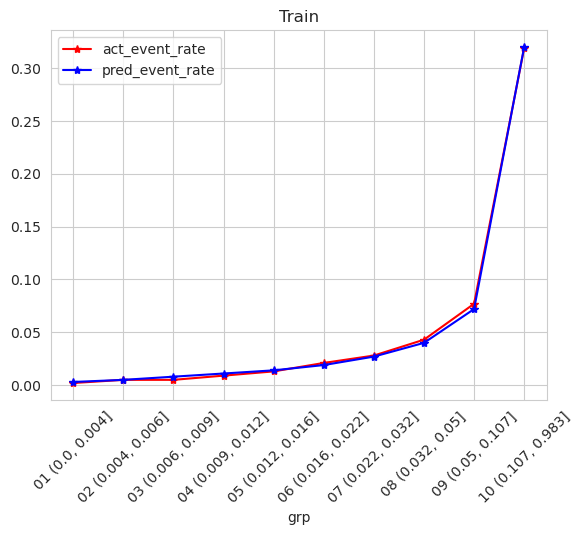

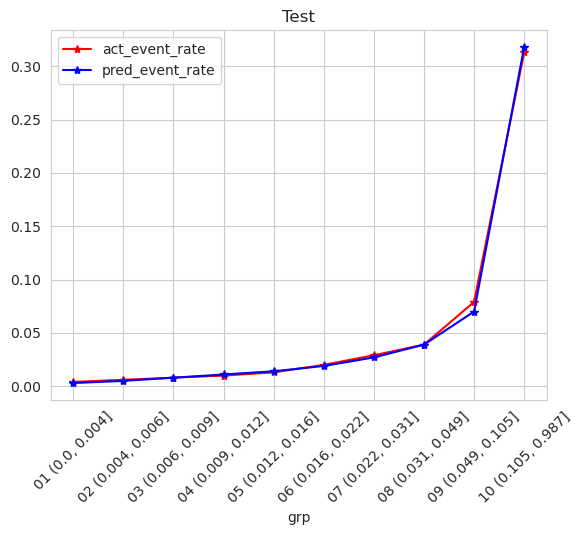

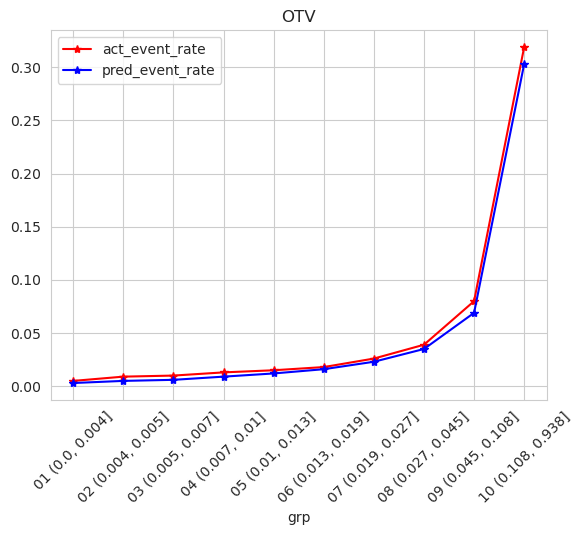

In [23]:
ror_train = exp_vs_act(df_train_encoded,'y_pred','label_90','Train')
ror_test = exp_vs_act(df_test_encoded,'y_pred','label_90','Test')
ror_val = exp_vs_act(df_val_encoded,'y_pred','label_90','OTV')

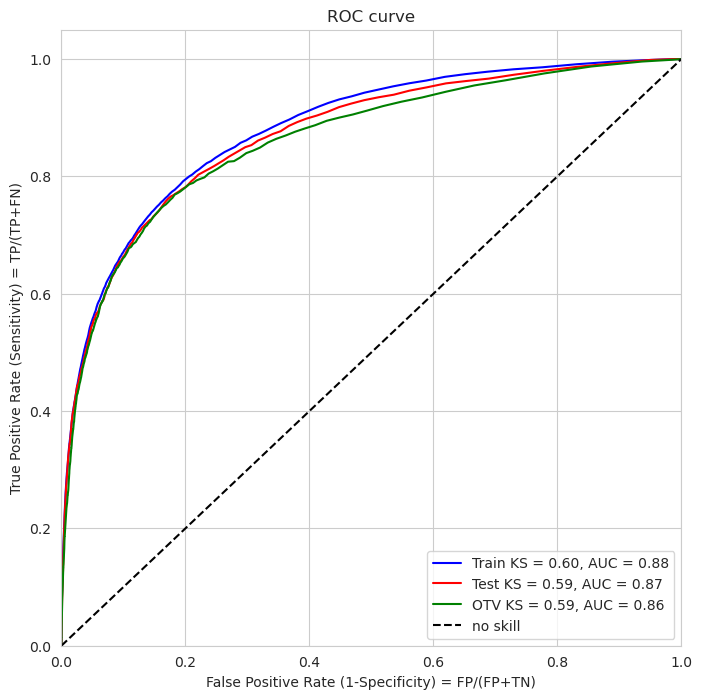

In [24]:
# from functions import plot_auc3
fig, ax = plt.subplots(1,1)
fig.set_size_inches(8,8)
# plot_auc2(ax, y_train, df_train['y_pred'], y_test, df_test['y_pred'])
plot_auc3(ax, y_train, df_train_encoded['y_pred'], y_test, df_test_encoded['y_pred'], df_val_encoded.label_90, df_val_encoded['y_pred'])

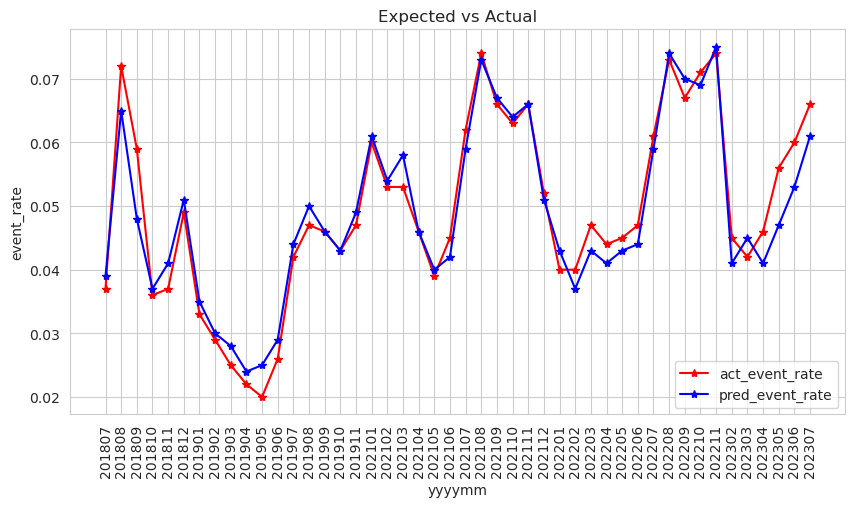

In [25]:
df_train_encoded['yyyymm'] = df_train_encoded['dt'].astype(str).str[:7].str.replace('-', '')
df_test_encoded['yyyymm'] = df_test_encoded['dt'].astype(str).str[:7].str.replace('-', '')
df_val_encoded['yyyymm'] = df_val_encoded['dt'].astype(str).str[:7].str.replace('-', '')

df = pd.concat([df_train_encoded,df_test_encoded,df_val_encoded])
target = 'label_90'
score = 'y_pred'
date = 'yyyymm'
exp_vs_act_date(df,score,date,target)

100%|===================| 57913/58001 [03:03<00:00]        

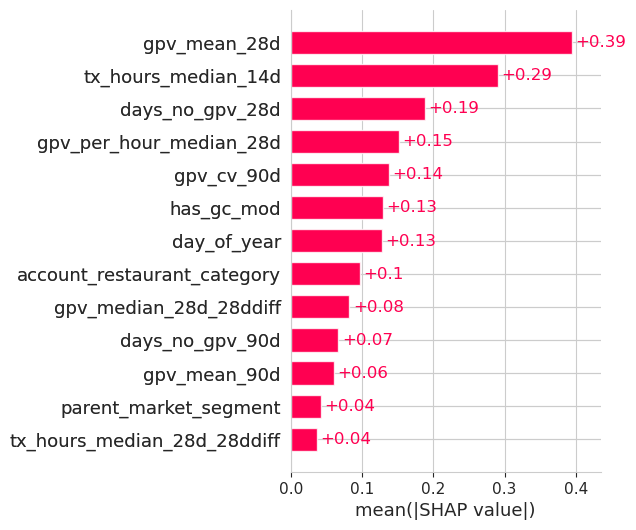

In [26]:
explainer = shap.Explainer(model, df_val_encoded[pd_features], feature_names=[pd_features])
shap_values = explainer(df_val_encoded[pd_features],check_additivity=False)
fig = plt.figure()
shap.plots.bar(shap_values, max_display=20,show = False)
plt.gcf().set_size_inches(4,6)
plt.show()

In [27]:
feature_names = shap_values.feature_names
shap_df = pd.DataFrame(shap_values.values, columns=feature_names)
vals = np.abs(shap_df.values).mean(0)
shap_importance = pd.DataFrame(list(zip(feature_names, vals)), columns=['col_name', 'feature_importance_vals'])
shap_importance.sort_values(by=['feature_importance_vals'], ascending=False, inplace=True)

In [28]:
shap_importance['%importance'] = round((shap_importance['feature_importance_vals']/shap_importance['feature_importance_vals'].sum()),2)
shap_importance

,col_name,feature_importance_vals,%importance
7,gpv_mean_28d,0.394415,0.22
11,tx_hours_median_14d,0.290545,0.16
3,days_no_gpv_28d,0.188605,0.10
10,gpv_per_hour_median_28d,0.152301,0.08
5,gpv_cv_90d,0.137817,0.08
6,has_gc_mod,0.129319,0.07
2,day_of_year,0.128557,0.07
0,account_restaurant_category,0.097141,0.05
9,gpv_median_28d_28ddiff,0.082383,0.05
4,days_no_gpv_90d,0.066987,0.04


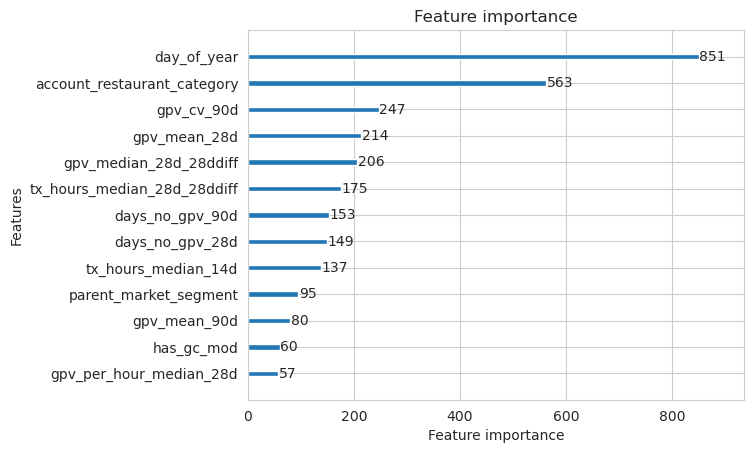

In [29]:
# Plot feature importance
lgb.plot_importance(model, importance_type='gain', max_num_features=20)  # You can adjust max_num_features as needed
plt.show()

In [30]:
print(f"AUC: {roc_auc_score(df_val_encoded['label_90'], df_val_encoded['y_pred']).round (3)}")
print()
print('Difference between average prediction and true default rate')
print(f"Diff in mean pred: {(df_val_encoded['y_pred'].mean() - df_val_encoded['label_90'].mean()).round(3)}")
print(f"Diff in std pred: {(df_val_encoded['y_pred'].std() - df_val_encoded['label_90'].std())}")

AUC: 0.863

Difference between average prediction and true default rate
Diff in mean pred: -0.005
Diff in std pred: -0.11816426454478357


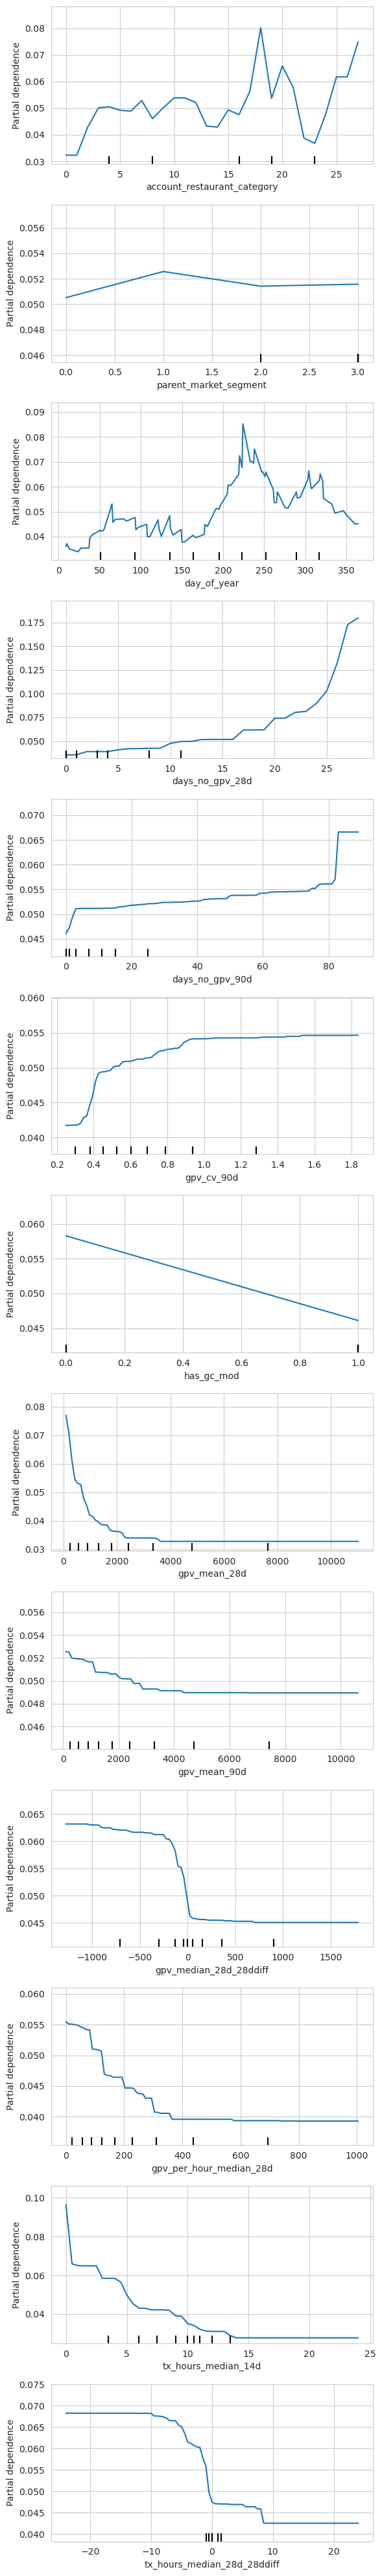

In [31]:
from sklearn.inspection import (partial_dependence, PartialDependenceDisplay)
n_cols = 1
n_rows = int(len(df_train_encoded[pd_features].columns)/n_cols)
fig, ax = plt.subplots(n_rows, n_cols, figsize=(6, 40))
tree_disp = PartialDependenceDisplay.from_estimator(model, df_train_encoded[pd_features], df_train_encoded[pd_features].columns, ax=ax, n_cols=n_cols)
for i in range(len(df_train_encoded[pd_features].columns)):
    ylim_min=tree_disp.lines_[i].get_ydata().min()
    ylim_max=tree_disp.lines_[i].get_ydata().max()
    q=tree_disp.axes_[i].set_ylim(ylim_min*.9,ylim_max*1.1)
fig.suptitle('')
fig.tight_layout()